Step 0: Load Dependencies

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from scipy.stats import ttest_ind
!pip install openpyxl

Step 1: Load and reshape data

In [89]:
#Define the sub-directory with your current dataset (and where you want the output files to go)
DATA_DIR = 'ComboA_FLZ'

In [91]:
#Define the file paths and replicate labels
file_paths = {
    'rep1': f'{DATA_DIR}/plate1.csv',
    'rep2': f'{DATA_DIR}/plate2.csv',
    'rep3': f'{DATA_DIR}/plate3.csv'
}

# Load and label
df_list = []
for rep, path in file_paths.items():
    df = pd.read_csv(path, index_col=0)  #This assumes the strains are listed in the first column of each row
    df['Replicate'] = rep
    df['Strain'] = df.index
    df_list.append(df.reset_index(drop=True))

#Combine everything into one dataframe
combined = pd.concat(df_list, ignore_index=True)

#Define the drug concentration columns (these are the column names as strings or numbers)
drug_columns = ['64', '32', '16', '8', '4', '2', '1', '0.5', '0.25', '0.125', '0.0625', '0']

#Make sure those columns are float
combined[drug_columns] = combined[drug_columns].astype(float)

#Melt only the below columns. This is necessary since analysis/plotting in pandas/scipy/matplotlib expects long format (each datapoint gets its own row)
melted = combined.melt(
    id_vars=['Replicate', 'Strain'],
    value_vars=drug_columns,
    var_name='Drug_Conc',
    value_name='OD600'
)
melted['Drug_Conc'] = melted['Drug_Conc'].astype(float)
df = melted

In [93]:
#Confirm the dataframe looks correct (ie. everything imported in the right orientation)
df

,Replicate,Strain,Drug_Conc,OD600
0,rep1,fRS1035,64.0,0.2802
1,rep1,fRS1042,64.0,0.2516
2,rep1,fRS1466,64.0,0.1378
3,rep1,fRS1481,64.0,0.7117
4,rep1,fRS1482,64.0,0.7843
...,...,...,...,...
427,rep3,fRS1,0.0,1.3215
428,rep3,fRS1050,0.0,1.3139
429,rep3,fRS1051,0.0,1.2929
430,rep3,fRS1052,0.0,1.2923


Step 2: Normalize each datapoint to the no-drug control well of the corresponding strain

In [96]:
no_drug = df[df['Drug_Conc'] == 0][['Replicate', 'Strain', 'OD600']].set_index(['Replicate', 'Strain'])
no_drug_dict = no_drug['OD600'].to_dict()

df['OD_norm'] = df.apply(lambda row: row['OD600'] / no_drug_dict[(row['Replicate'], row['Strain'])], axis=1)

#Remove 0 µg/mL for curve fitting (normalization already handled it)
df_fit = df[df['Drug_Conc'] != 0]

Step 3: Fit a 4-parameter logistic dose-response function to the data for each strain, as follows:

$$f(x) = c + \frac{d - c}{1 + (x/e)^{b}}$$

Here, c and d are the lower and upper asymptotes (ie. the concentrations that elicit the maximum and maximally-inhibited OD600 responses, respectively), e is the IC50 (concentration at half-maximal inhibition), and b is the Hill slope describing curve steepness. Model fitting is performed independently for each replicate, and IC50 values that fall outside of the tested concentration range are excluded as implausible. The actual reported IC50 values represent the mean across three biological replicates.

This is mathematically equivalent to the four-parameter logistic model used by GraphPad Prism (https://www.graphpad.com/guides/prism/6/curve-fitting/reg_dr_inhibit_variable.htm) that handles raw drug concentrations rather than log-transformed values as the input.

In [99]:
#Logistic dose-response function (4-parameter)
def logistic(x, bottom, top, ic50, hill_slope):
    return bottom + (top - bottom) / (1 + (x / ic50)**hill_slope)

#Fit per strain-replicate combo
ic50_values = []
grouped = df_fit.groupby(['Strain', 'Replicate'])
print(df_fit['Drug_Conc'].unique())

for (strain, rep), subdf in grouped:
    x = subdf['Drug_Conc'].values
    y = subdf['OD_norm'].values

    #Skip problematic values before fitting
    if np.any(x <= 0) or np.any(np.isnan(x)) or np.any(np.isnan(y)):
        print(f"Skipping Input for Strain: {strain}, Replicate: {rep}")
        ic50_values.append({'Strain': strain, 'Replicate': rep,
                            'Bottom': np.nan, 'Top': np.nan,
                            'IC50': np.nan,   'Hill': np.nan})
        continue

    #Initial parameter guesses: [bottom, top, ic50, hill_slope]
    p0 = [min(y), max(y), np.median(x), 1.0]
    bounds = ([-np.inf, -np.inf, 1e-9, -np.inf],
              [ np.inf,  np.inf, max(x),  np.inf])

    try:
        popt, _ = curve_fit(logistic, x, y, p0=p0, bounds=bounds, maxfev=10000)
        bottom, top, ic50, hill = popt
        ic50_values.append({'Strain': strain, 'Replicate': rep,
                            'Bottom': bottom, 'Top': top,
                            'IC50': ic50,     'Hill': hill})
    except RuntimeError:
        print(f"Curve fitting Failed for Strain: {strain}, Replicate: {rep}")
        ic50_values.append({'Strain': strain, 'Replicate': rep,
                            'Bottom': np.nan, 'Top': np.nan,
                            'IC50': np.nan,   'Hill': np.nan})

[6.40e+01 3.20e+01 1.60e+01 8.00e+00 4.00e+00 2.00e+00 1.00e+00 5.00e-01
 2.50e-01 1.25e-01 6.25e-02]


In [101]:
#Save the IC50 values and other model parameters to a dataframe
ic50_df = pd.DataFrame(ic50_values)

Step 4: Generate a rough plot of the IC50 values for a quick look

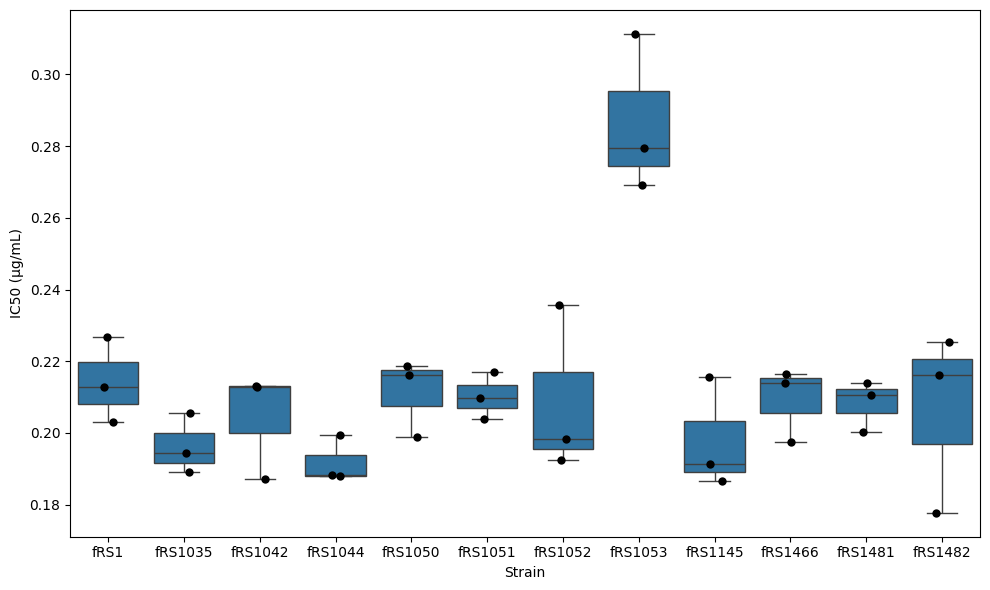

In [104]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=ic50_df, x='Strain', y='IC50')
sns.stripplot(data=ic50_df, x='Strain', y='IC50', color='black', size=6, jitter=True)

plt.ylabel('IC50 (µg/mL)')
plt.xlabel('Strain')
plt.tight_layout()
plt.show()

In [106]:
#Save IC50 values to an Excel file
ic50_df.to_excel(f'{DATA_DIR}/IC50_values.xlsx', index=False)

Step 5: Visualize the dose-response curves for each strain for interest

Figure saved to ComboA_FLZ/dose_response_curves.png


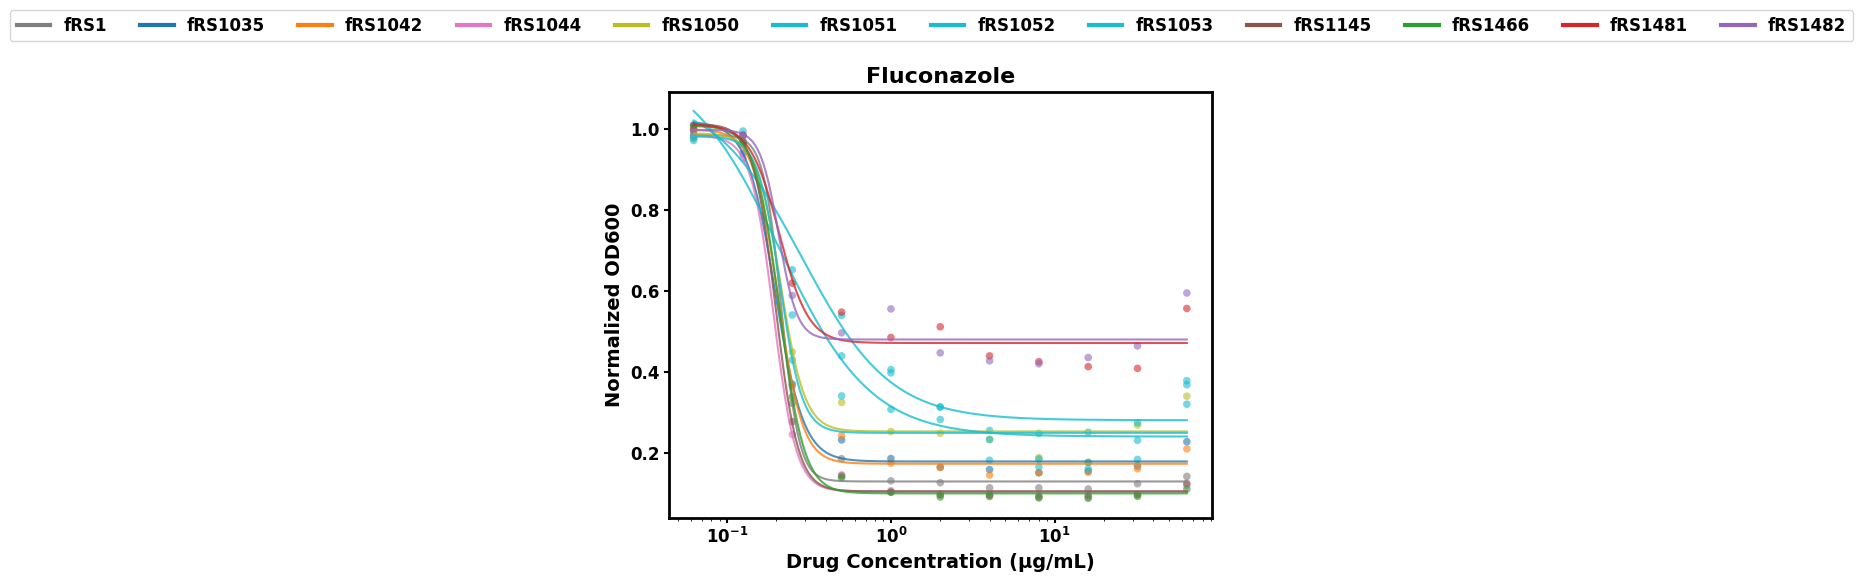

In [109]:
#Auto-assign a random distinct colour to each strain
strains    = df_fit['Strain'].unique()
cmap       = plt.colormaps['tab10']
STRAIN_COLORS = {strain: cmap(i) for i, strain in enumerate(strains)}

DRUG_LABEL   = 'Fluconazole'              #Title / axis label
OUTPUT_FILE  = f'{DATA_DIR}/dose_response_curves.png' #Saved to the same sub-directory as the input data

#Average the fitted model parameters across replicates for each strain
strain_params = (
    ic50_df.groupby('Strain')[['Bottom', 'Top', 'IC50', 'Hill']]
    .mean()
    .dropna()
)

#Make the plot
fig, ax = plt.subplots(figsize=(7, 6))

for strain, row in strain_params.iterrows():
    color = STRAIN_COLORS.get(strain, '#7f7f7f')

    #Scatter: per-concentration mean across replicates
    strain_data = df_fit[df_fit['Strain'] == strain]
    avg = strain_data.groupby('Drug_Conc')['OD_norm'].mean().reset_index()
    ax.scatter(avg['Drug_Conc'], avg['OD_norm'],
               color=color, s=30, alpha=0.6, edgecolors='none')

    #Smooth fitted curve using mean parameters
    x_min, x_max = avg['Drug_Conc'].min(), avg['Drug_Conc'].max()
    x_smooth = np.logspace(np.log10(x_min), np.log10(x_max), 200)
    y_smooth = logistic(x_smooth, row['Bottom'], row['Top'], row['IC50'], row['Hill'])
    ax.plot(x_smooth, y_smooth, color=color, lw=1.5, alpha=0.8)

ax.set_xscale('log')
ax.set_xlabel('Drug Concentration (μg/mL)', fontsize=14, fontweight='bold')
ax.set_ylabel('Normalized OD600', fontsize=14, fontweight='bold')
ax.set_title(DRUG_LABEL, fontsize=16, fontweight='bold')
ax.grid(False)
for spine in ax.spines.values():
    spine.set_linewidth(2)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

#Legend
legend_handles = [
    plt.Line2D([0], [0], color=STRAIN_COLORS[s], lw=3, label=s)
    for s in strain_params.index
]
plt.subplots_adjust(top=0.82)
legend = fig.legend(handles=legend_handles, loc='upper center',
                    bbox_to_anchor=(0.5, 0.97), ncol=len(legend_handles),
                    fontsize=12, frameon=True)
for text in legend.get_texts():
    text.set_fontweight('bold')

if OUTPUT_FILE:
    plt.savefig(OUTPUT_FILE, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'Figure saved to {OUTPUT_FILE}')
plt.show()